In [1]:

import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

plot shap value distributions for the most frequent important tokens of all runs for class 1

In [3]:
# load all runs outputs and filter the most important tokens in each run, then find tokens frequently are present as important in all runs

dfs = [pd.read_csv(f"/p/project1/hai_dnaori/piroozeh1/DNABERT_2/finetune/shap-values/nsample_100_aic/shap_values{i}.csv") for i in range(1, 31)]

top_tokens_all = []

for df in dfs:
    cutoff = 1
    df = df[df["shap_value"].abs() < cutoff] # eliminate extremely high shap values which are outleiers
    ab = df[(df["class"] == 1) & (df["shap_value"] > 0)]
    
    
    top_tokens = (
        ab.groupby("token")
        .agg(
            mean_shap=("shap_value", "mean"),
            sum_shap=("shap_value", "sum"),
            count=("shap_value", "count")
        )
        .sort_values("mean_shap", ascending=False)
        .head(50)
        .reset_index()
    )
    
    top_tokens_all.append(top_tokens)

# Concatenate all top token results
combined_top_tokens = pd.concat(top_tokens_all)

# Group by token across all dataframes
final_agg = (
    combined_top_tokens.groupby("token")
    .agg(
        freq_in_runs=("token", "count"),  # in how many runs this token was in top 30
        total_count=("count", "sum"),      # sum of counts in all runs
        avg_shap=("mean_shap", "mean")
    )
    .sort_values(["freq_in_runs", "avg_shap"], ascending=False)
)

print(final_agg.head(40))
freq_important_tokens= final_agg.head(40).index.tolist()


                                  freq_in_runs  total_count  avg_shap
token                                                                
AAAAAAAA                                    20           32  0.087552
TAGTTTT                                     18           29  0.087283
GTGTGTG                                     15           15  0.070021
TATATATATATATATA                            13           24  0.076164
TAAAAAAA                                    12           28  0.086901
CTTAATT                                     12           18  0.077311
TATTTA                                      11           11  0.082129
TATATATATATATATATATATATATATATATA            11           11  0.079899
TATTTAA                                     11           19  0.069037
AAAAAAAAAAAAAAA                             10           10  0.082308
TAAATTA                                     10           27  0.076150
TTTTAATT                                    10           11  0.075111
TATATATA            

In [4]:

# Collect all shap values where class == 1
all_class1 = pd.concat([df[df["class"] == 1] for df in dfs], ignore_index=True)



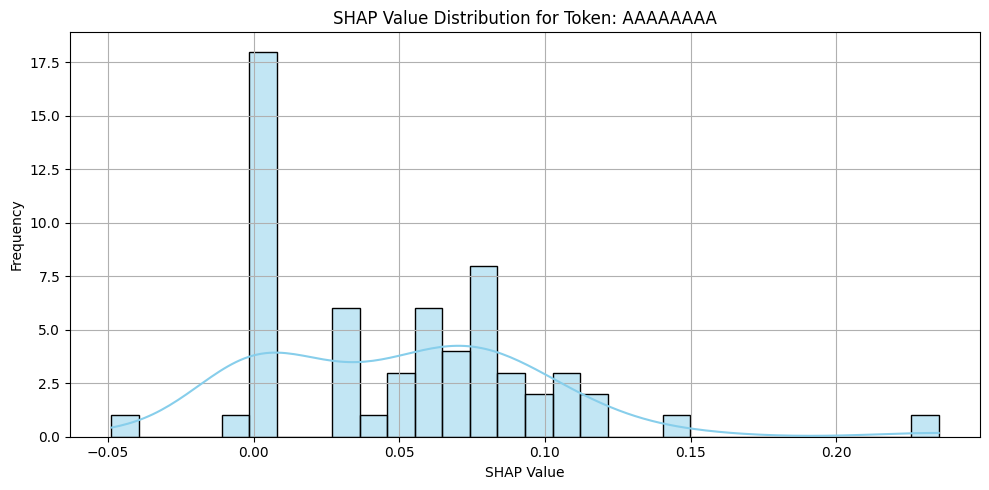

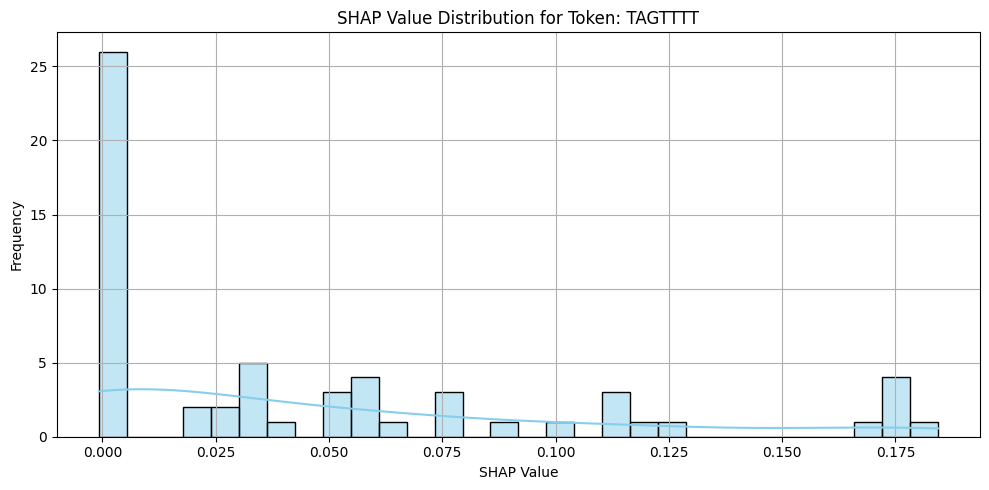

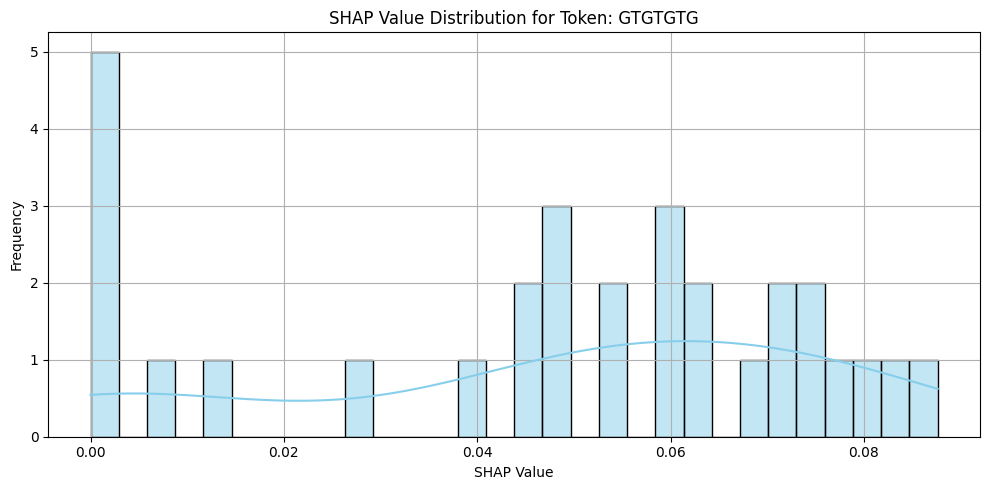

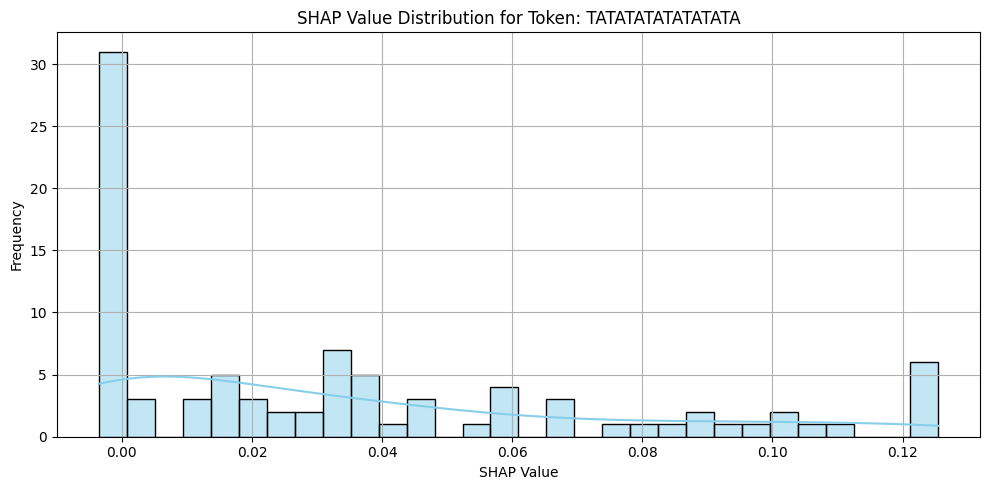

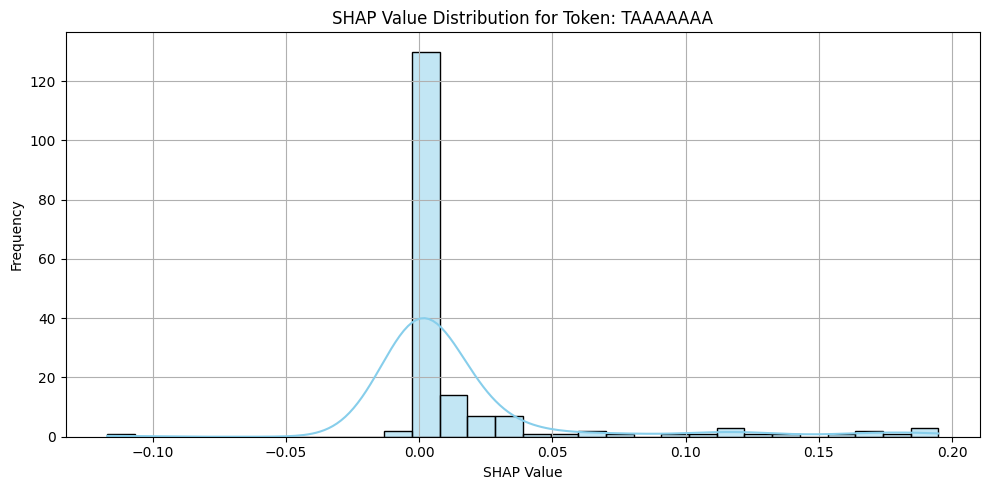

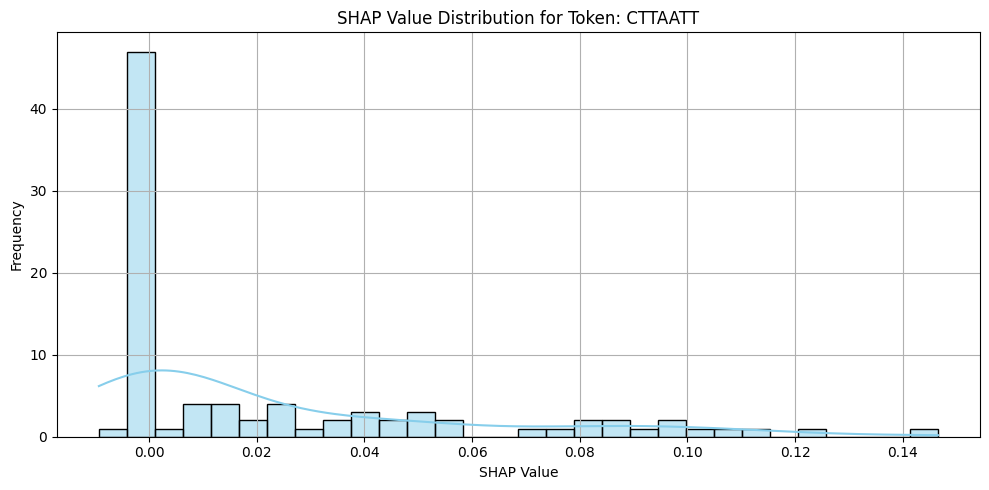

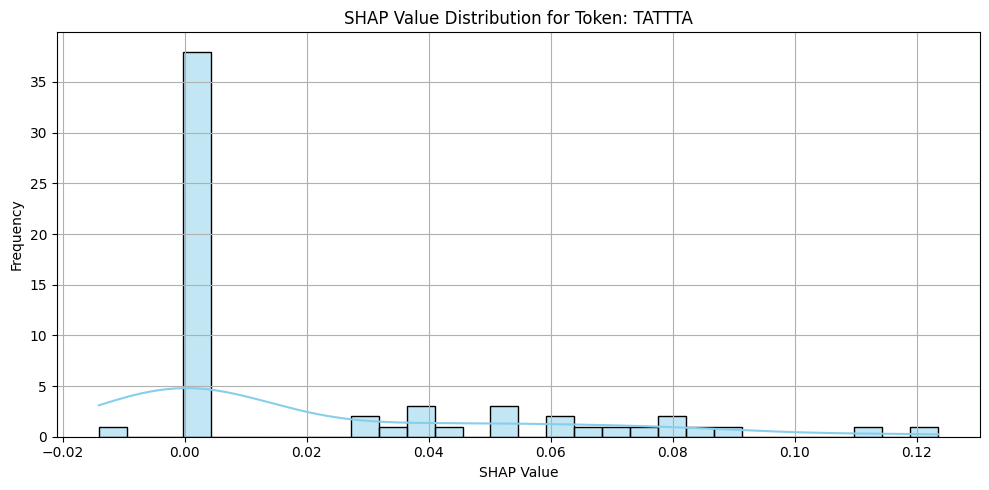

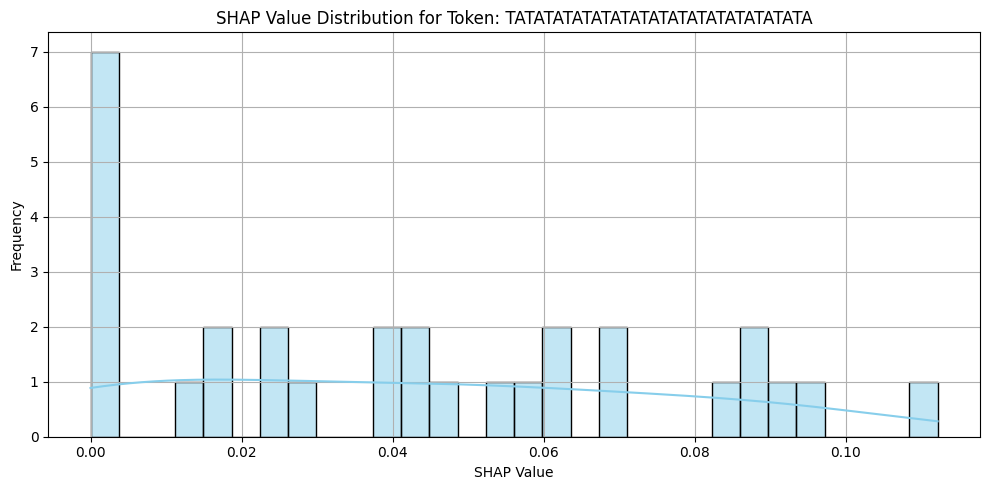

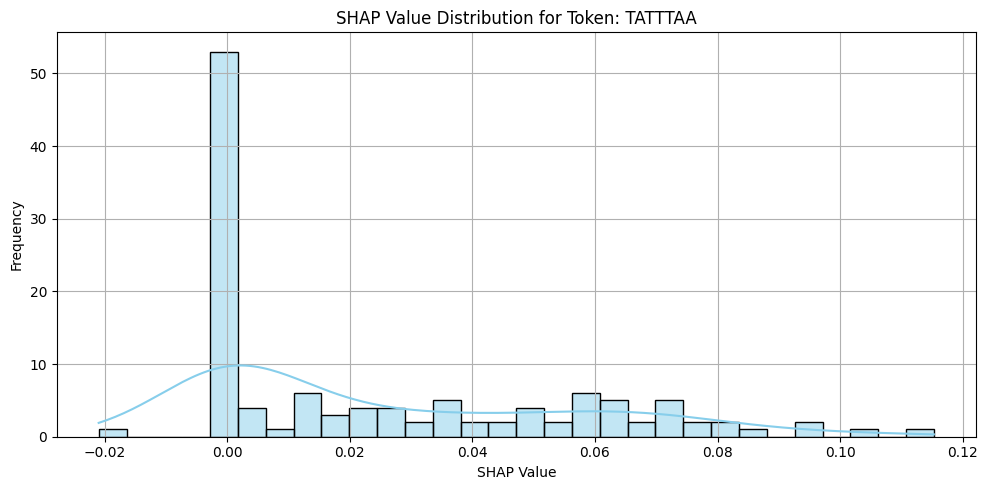

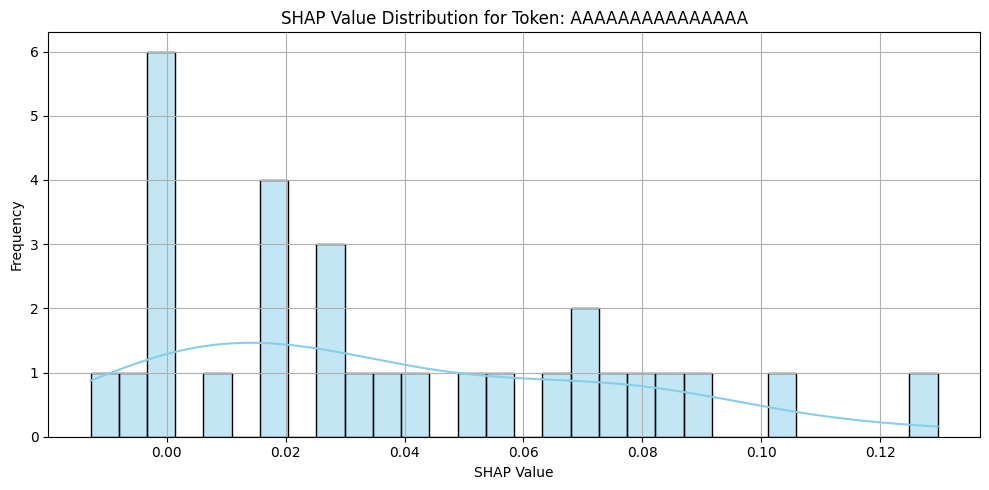

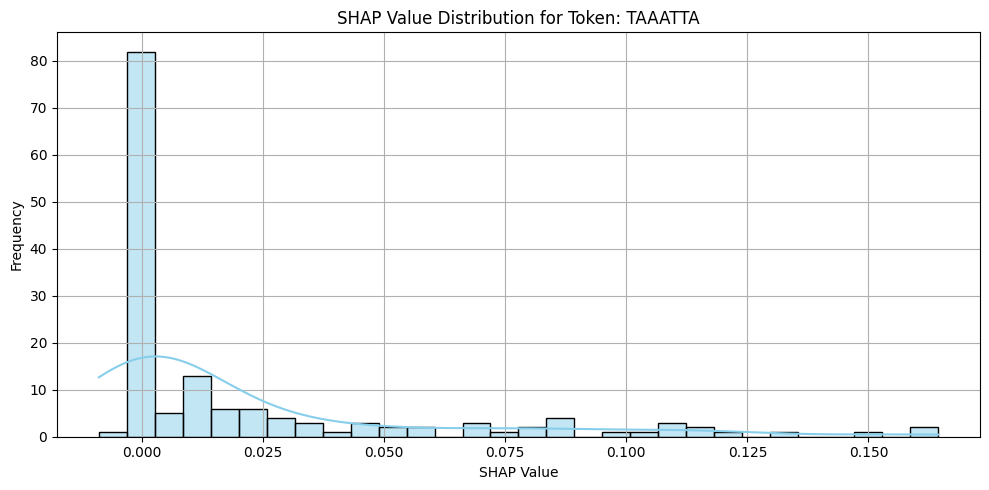

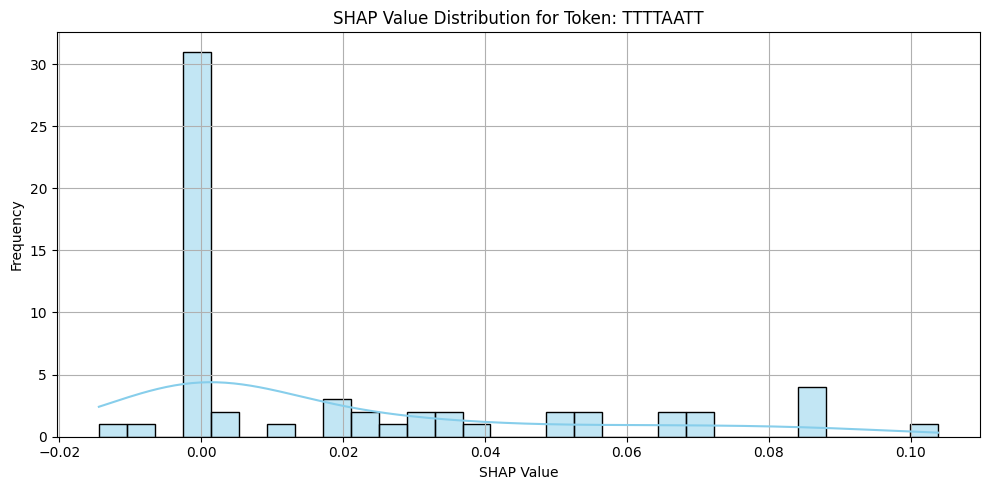

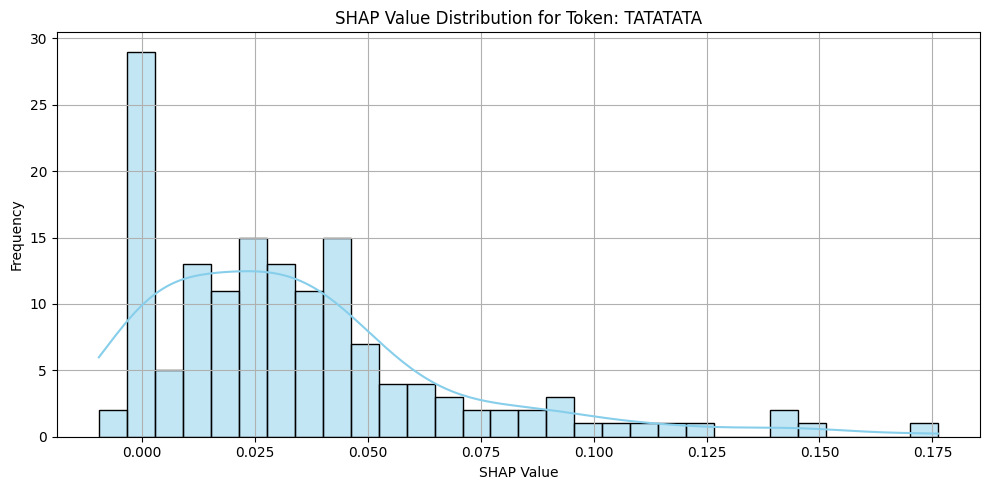

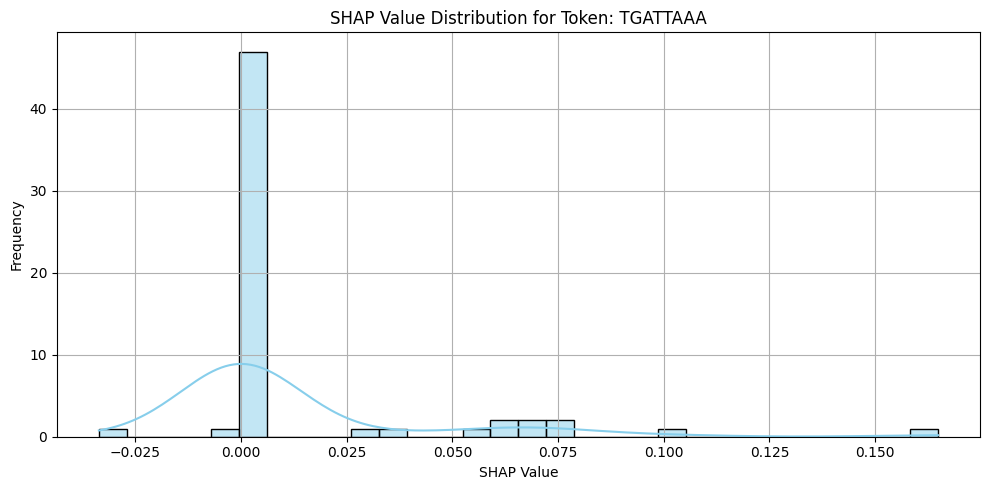

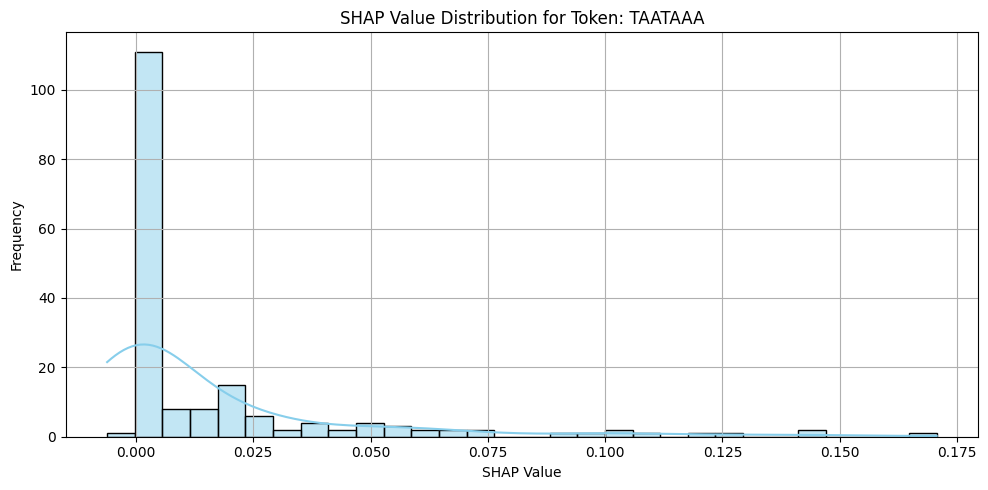

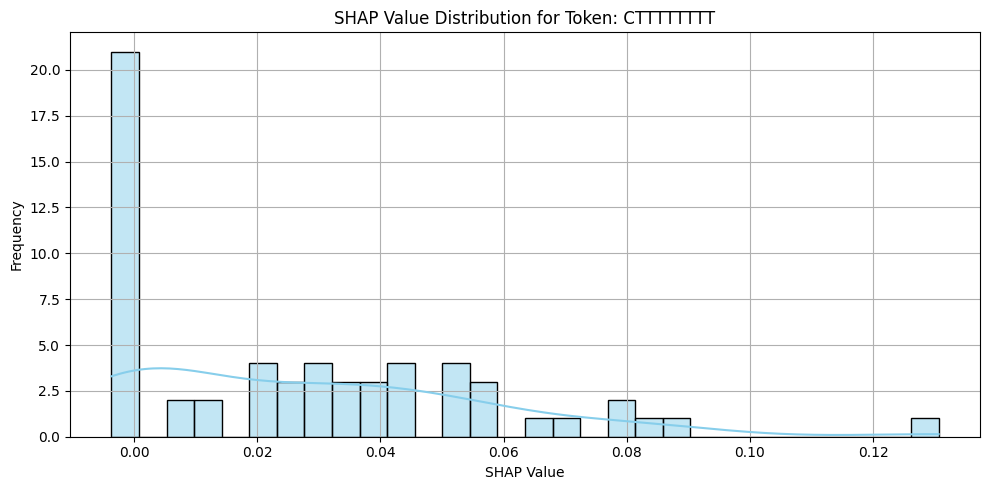

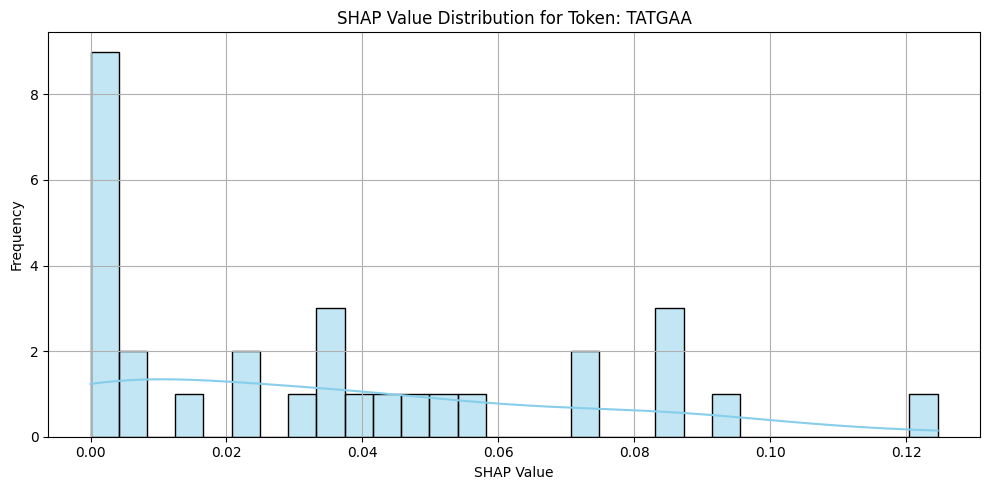

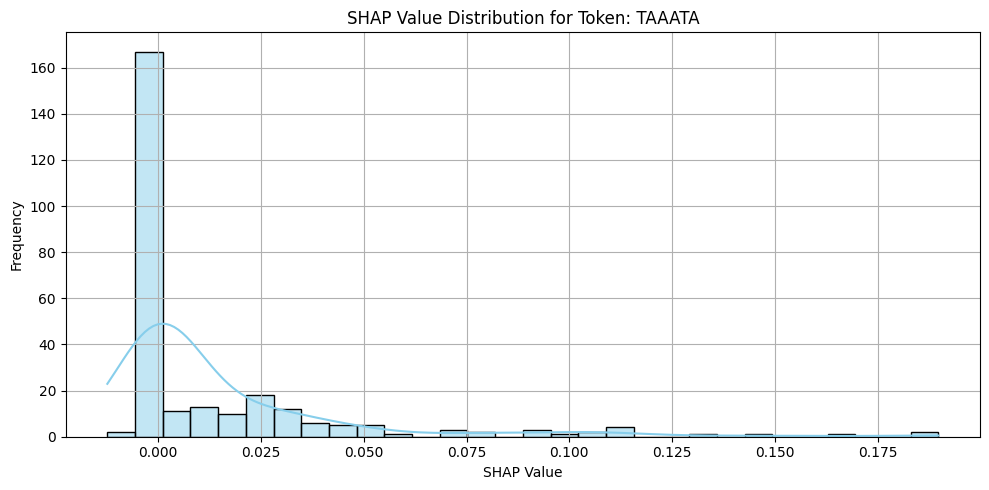

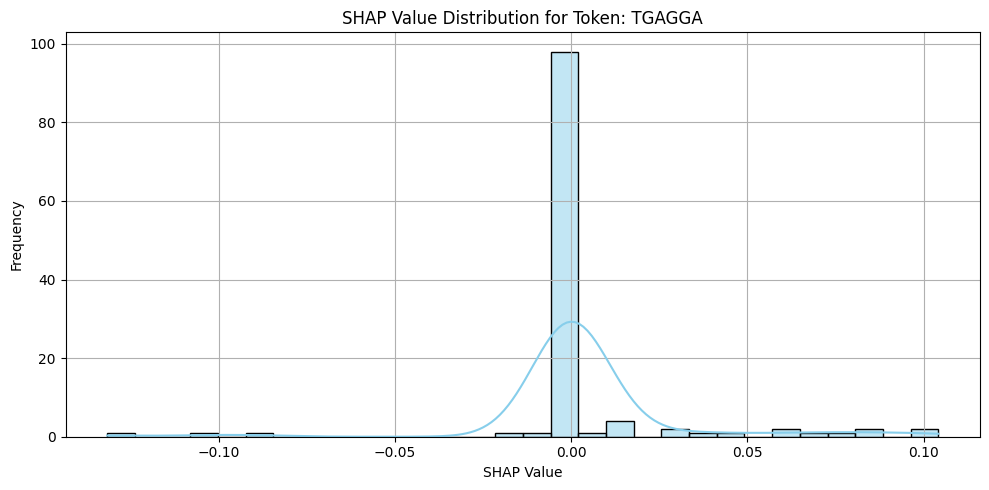

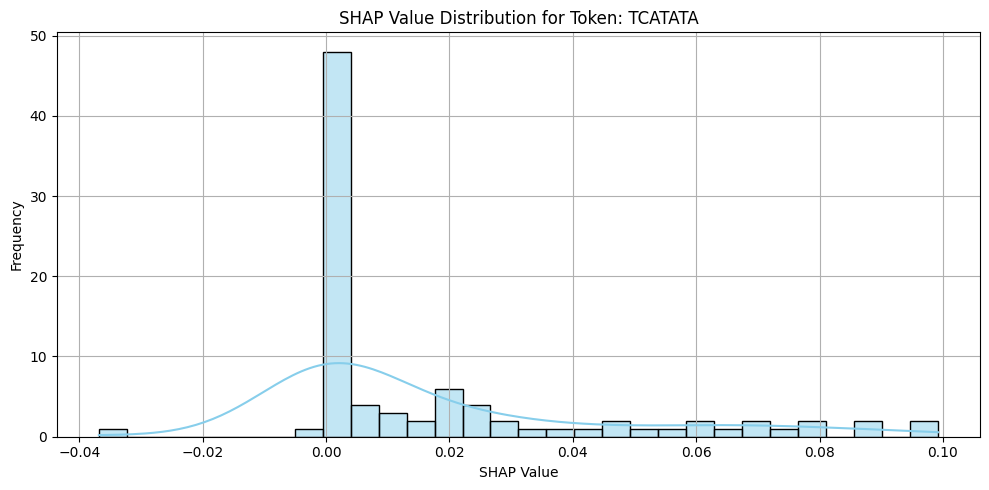

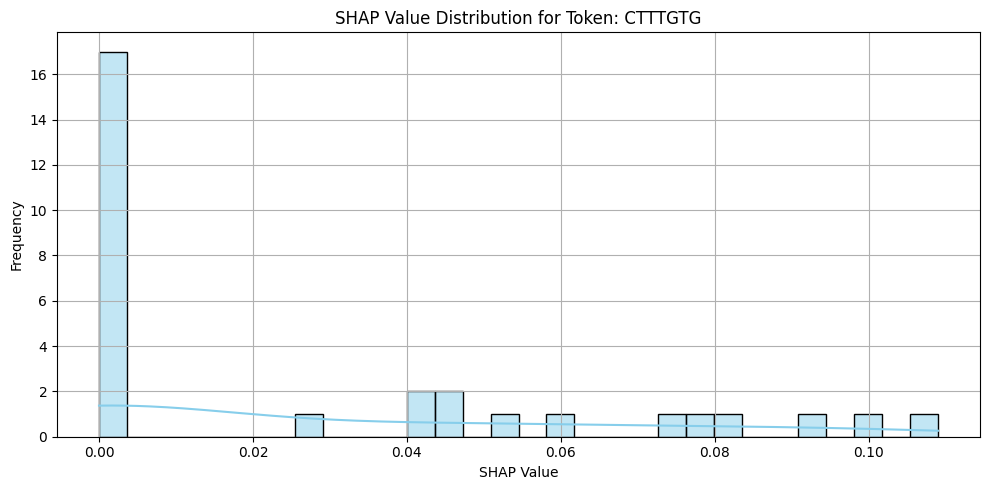

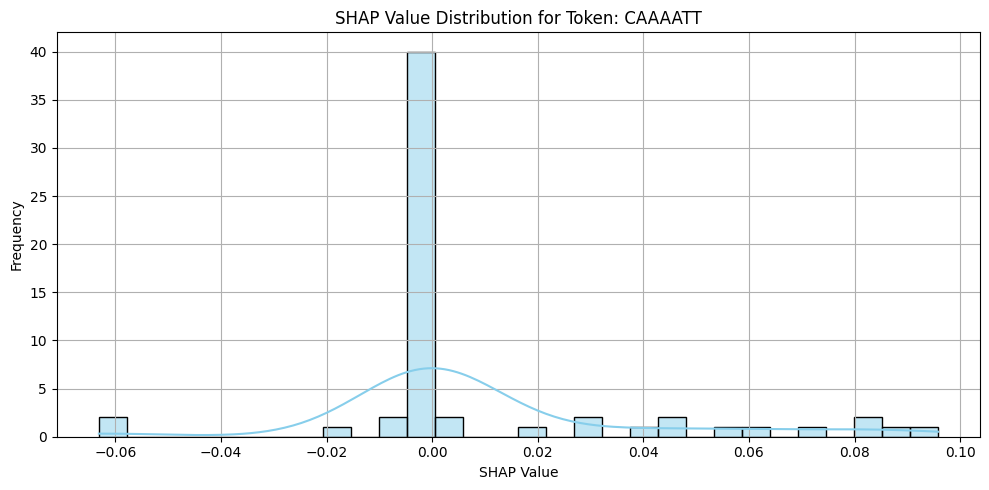

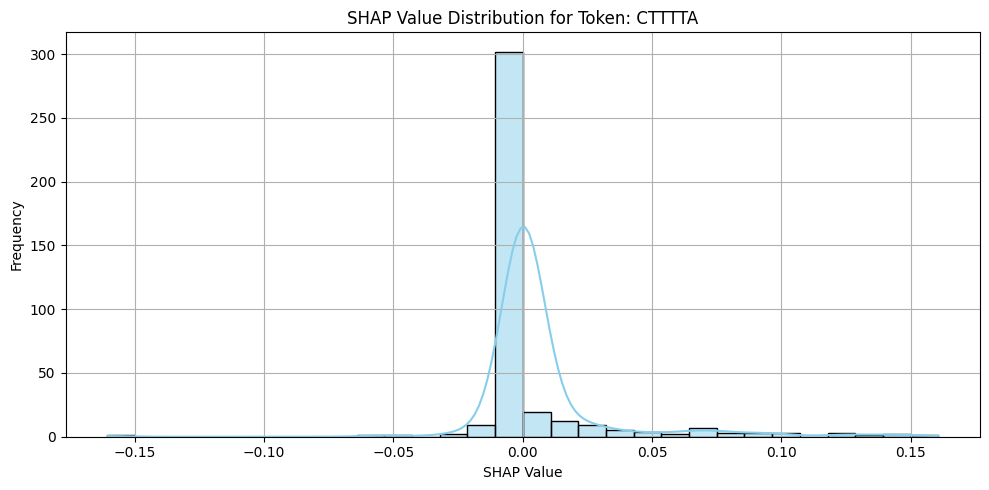

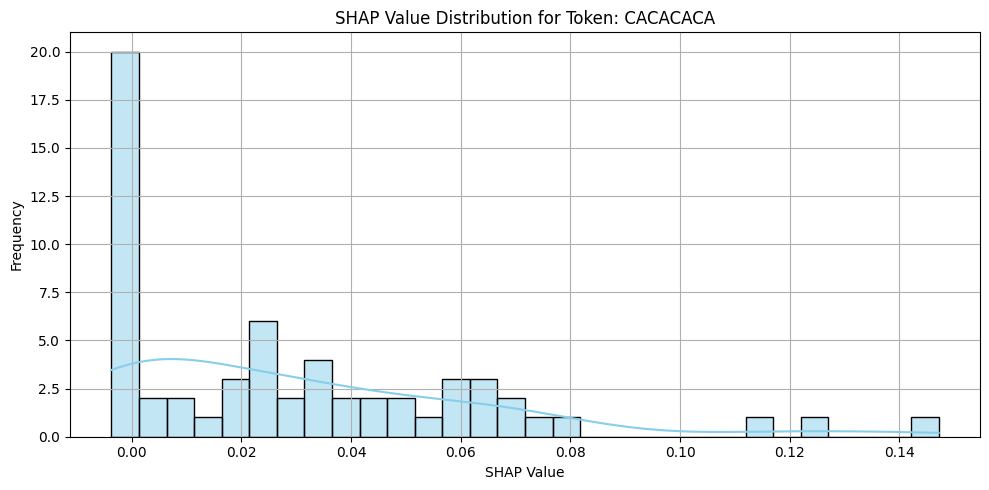

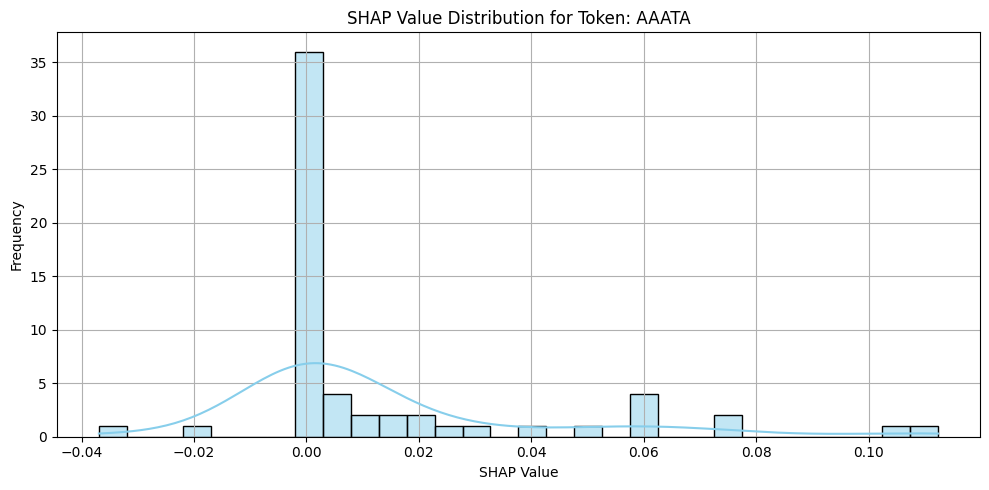

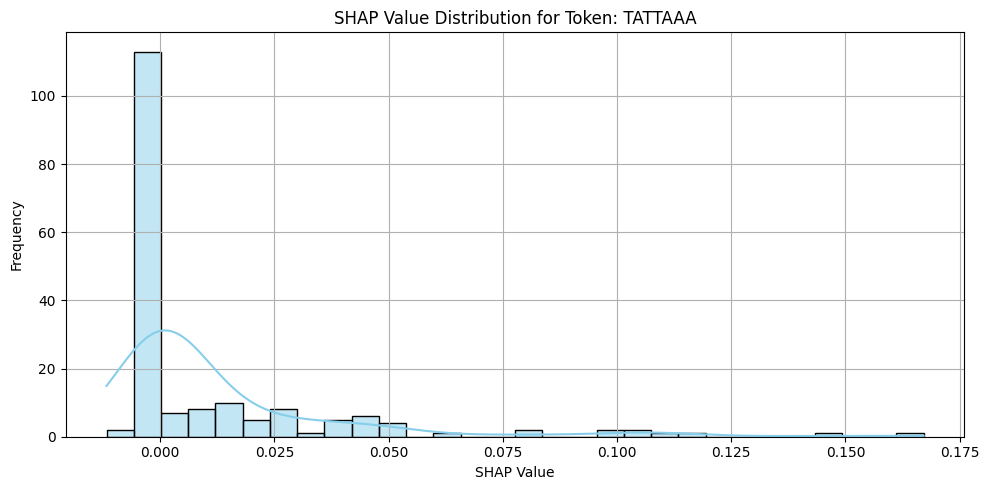

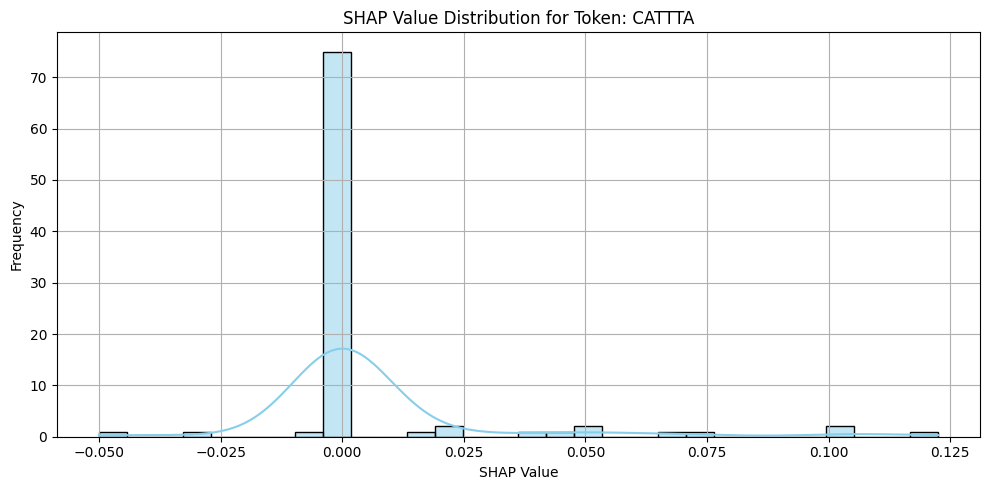

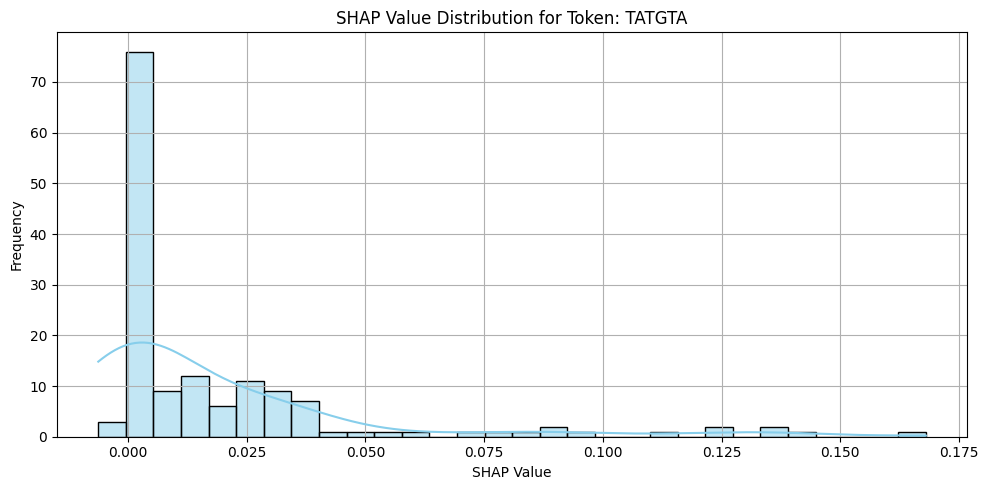

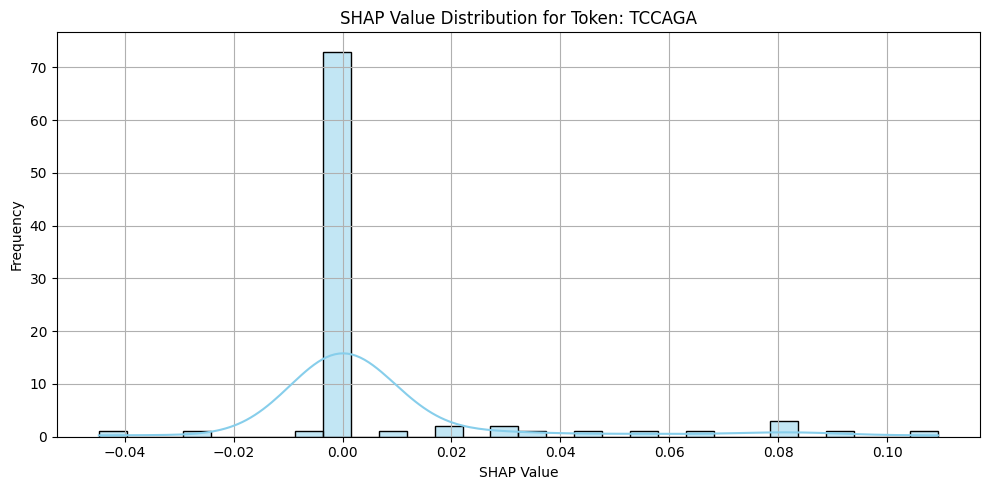

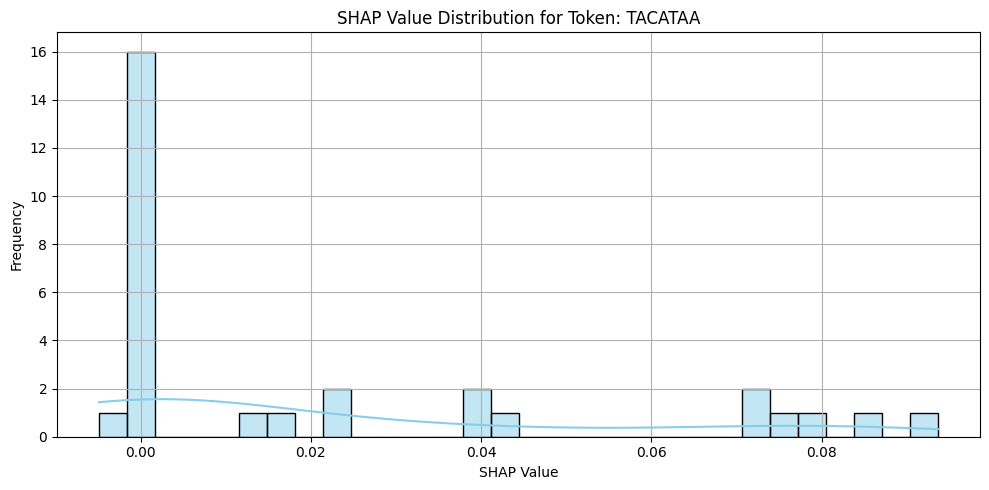

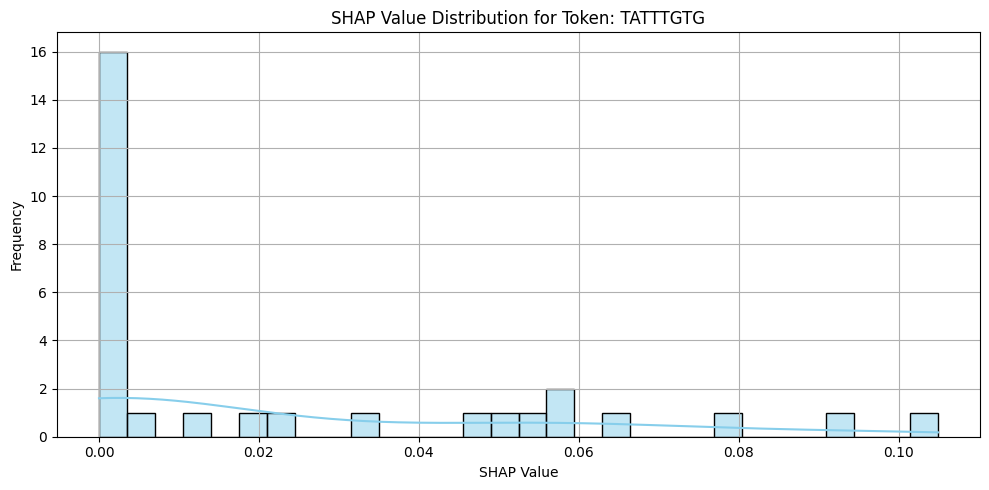

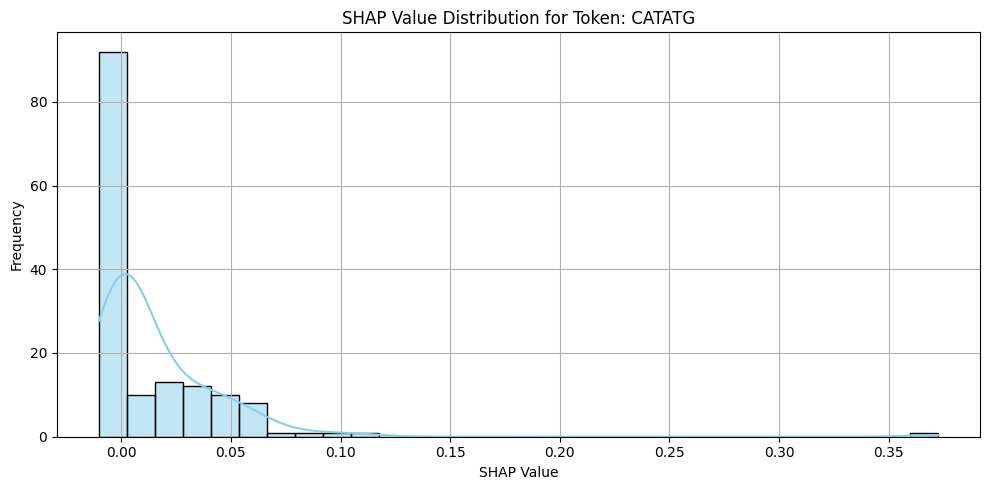

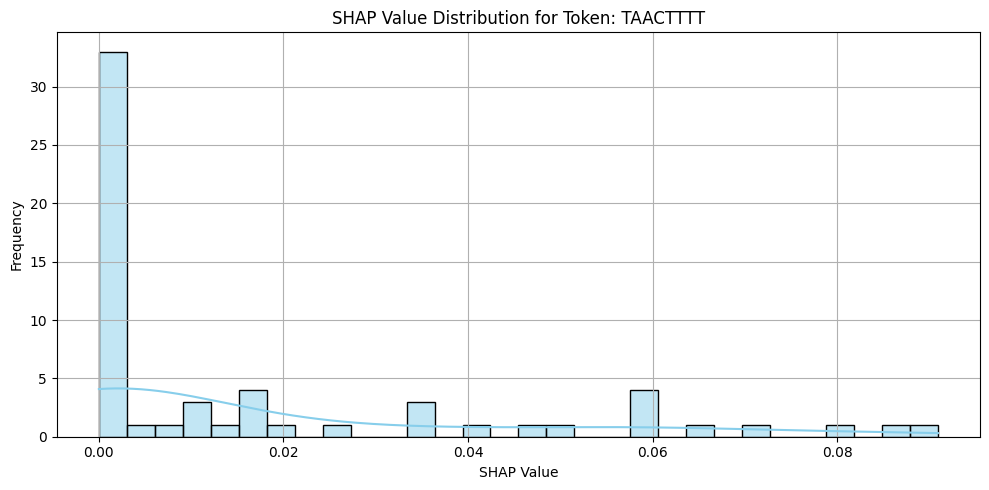

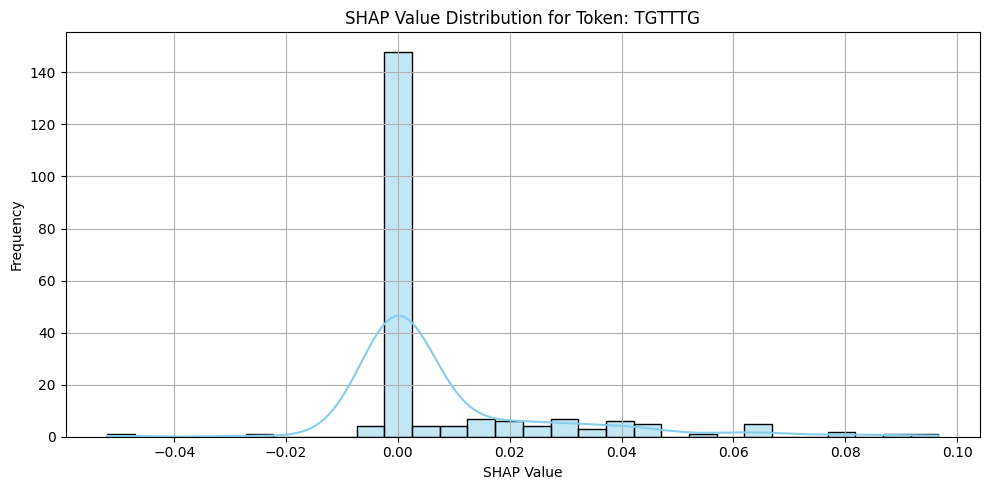

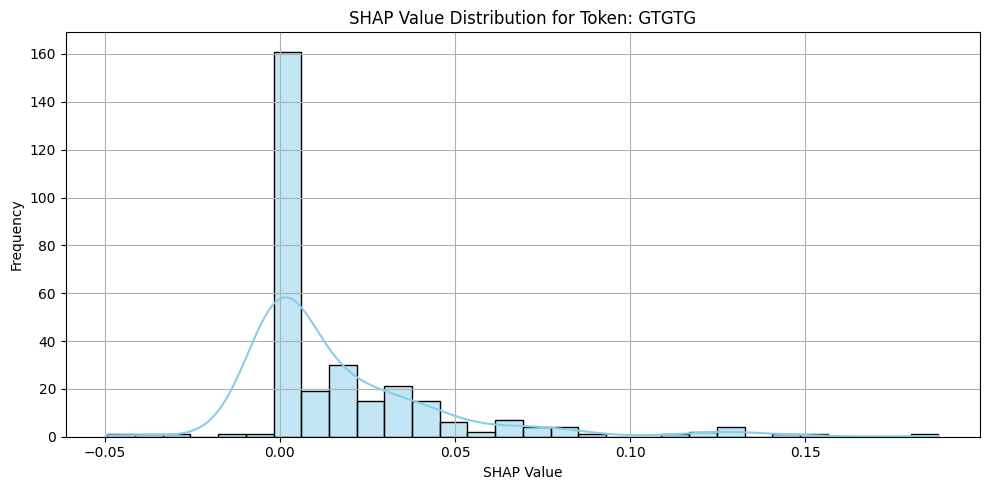

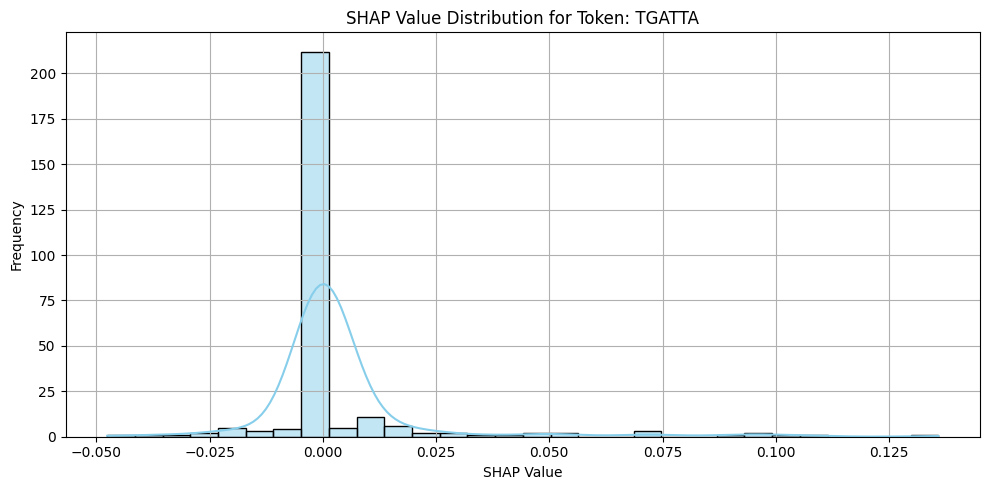

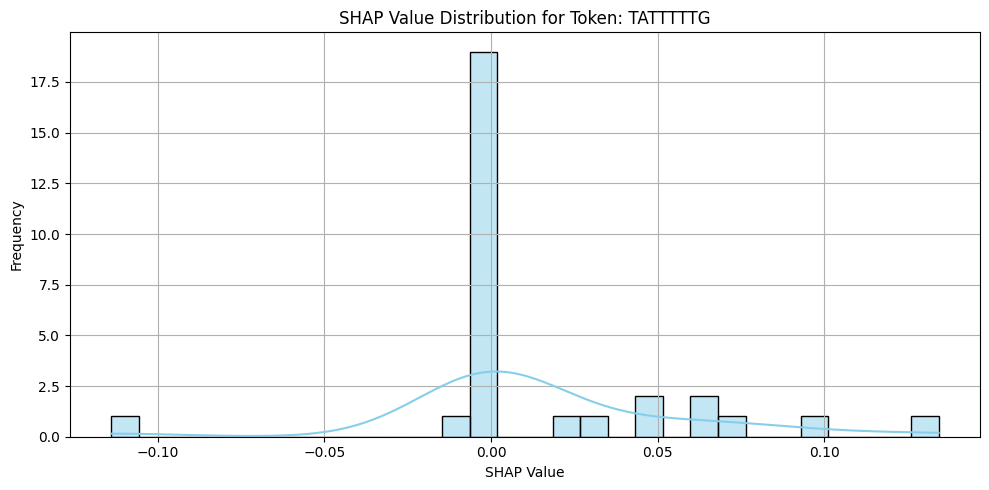

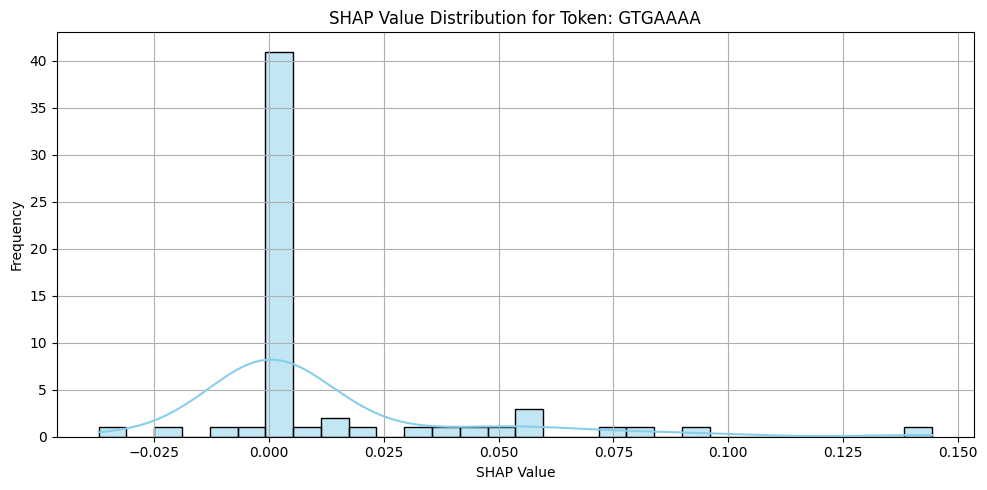

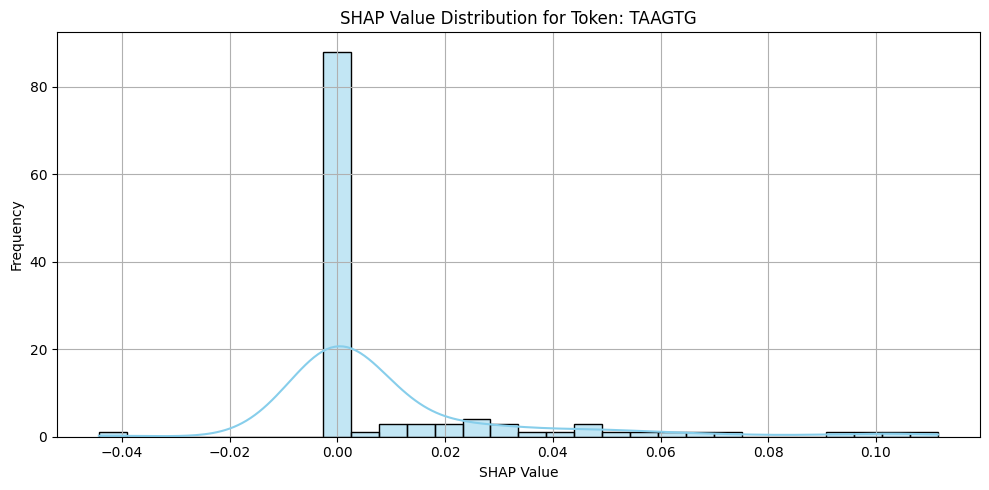

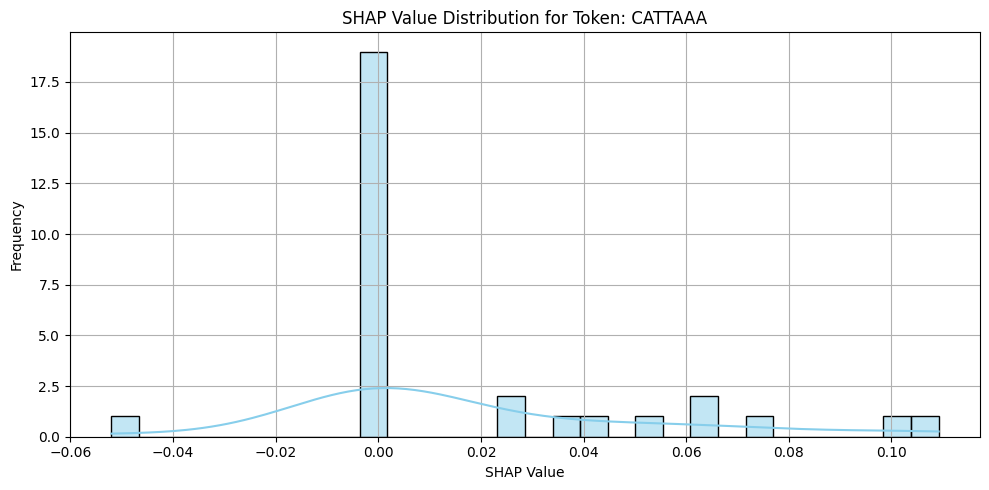

In [5]:
for token in freq_important_tokens:
   
    token_shap_values = all_class1[all_class1["token"] == token]
    
    # Plot the distribution
    plt.figure(figsize=(10, 5))
    sns.histplot(token_shap_values["shap_value"], bins=30, kde=True, color='skyblue')
    plt.title(f"SHAP Value Distribution for Token: {token}")
    plt.xlabel("SHAP Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()